# Exercise 2

This notebook follows Problem 2 of the exam brief: evaluate entanglement properties of a neural quantum state. The focus is not variational training yet, but rather the state representation, sampling logic, SWAP-based Renyi-2 estimation, and the behavior of randomly initialized networks under disorder averaging.

The required report evidence is the exact-vs-sampled random-state study below. The larger-system training benchmark is kept, but it is labeled explicitly as an optional validation appendix rather than core Problem 2 evidence.


In [1]:
from notebook_bootstrap import bootstrap_notebook

bootstrap_notebook(enable_x64=True)

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from exercise_report_helper import (
    build_output_manifest,
    ensure_report_output_dir,
    save_report_figure,
    save_report_table,
)
from nqs.workflows import run_non_ed_vmc_benchmark, run_random_architecture_study

In [3]:
study_config = {
    'lattice_shape': (2, 2),
    'pbc': False,
    'hamiltonian': 'tfim',
    'J': 1.0,
    'h': 1.0,
    'n_samples': 128,
    'n_discard_per_chain': 32,
    'n_chains': 16,
}

exercise_output_dir = ensure_report_output_dir('exercise_2')
exercise_output_dir

WindowsPath('C:/Users/balin/PycharmProjects/NQS/Balint/demos/report_outputs/exercise_2')

## Report Setup And Reproducibility

The main report path for Problem 2 is the disorder-averaged random-state study on an open `2x2` TFIM benchmark, because that keeps exact and sampled Renyi-2 on the same page. The later non-ED training benchmark is retained only as an appendix-style validation section.

All stochastic results are controlled by explicit seed lists in the cells below. JAX `x64` is enabled through `bootstrap_notebook(...)`, and the export cell writes the report artifacts to `demos/report_outputs/exercise_2/`. Re-running the notebook from top to bottom regenerates the inline outputs and the exported files together.


In [4]:
exercise_2_run_context = pd.DataFrame([
    {'item': 'main_system', 'value': f"{study_config['lattice_shape']} open TFIM, J={study_config['J']}, h={study_config['h']}"},
    {'item': 'sampling_config', 'value': f"n_samples={study_config['n_samples']}, n_discard_per_chain={study_config['n_discard_per_chain']}, n_chains={study_config['n_chains']}"},
    {'item': 'swap_demo_seeds', 'value': (0,)},
    {'item': 'disorder_average_seeds', 'value': (0, 1, 2, 3)},
    {'item': 'architecture_scan_seeds', 'value': (0, 1, 2)},
    {'item': 'large_benchmark_mode', 'value': 'Optional validation appendix on 4x4 and 5x5 open TFIM'},
    {'item': 'backend', 'value': 'Project NQS workflow with JAX x64 enabled in-notebook'},
    {'item': 'output_dir', 'value': str(exercise_output_dir)},
    {'item': 'rerun_guidance', 'value': 'Use Run All; the export cell rewrites CSV/HTML/PNG report artifacts.'},
])
exercise_2_run_context

,item,value
0,main_system,"(2, 2) open TFIM, J=1.0, h=1.0"
1,sampling_config,"n_samples=128, n_discard_per_chain=32, n_chain..."
2,swap_demo_seeds,"(0,)"
3,disorder_average_seeds,"(0, 1, 2, 3)"
4,architecture_scan_seeds,"(0, 1, 2)"
5,large_benchmark_mode,Optional validation appendix on 4x4 and 5x5 op...
6,backend,Project NQS workflow with JAX x64 enabled in-n...
7,output_dir,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
8,rerun_guidance,Use Run All; the export cell rewrites CSV/HTML...


## 2/a Neural Quantum State Representation

We represent the wavefunction as a neural network $\psi_	heta(\sigma)$ that maps a spin configuration $\sigma$ to a complex log-amplitude. For the required architecture families we use:

- `RBM` as the reference compact ansatz;
- `FFNN` as a generic fully connected baseline;
- `CNN` as the explicitly local architecture.

The network interface is shared across architectures, so the downstream sampling and entropy-estimation code depends only on the variational-state API rather than on a specific ansatz implementation.


In [5]:
architecture_table = pd.DataFrame([
    {'model': 'RBM', 'model_kwargs': {'alpha': 1}, 'role': 'reference compact ansatz'},
    {'model': 'FFNN', 'model_kwargs': {'hidden_dims': (8,)}, 'role': 'fully connected baseline'},
    {'model': 'CNN', 'model_kwargs': {'channels': (4,), 'kernel_size': (2, 2)}, 'role': 'local architecture'},
])
architecture_table

,model,model_kwargs,role
0,RBM,{'alpha': 1},reference compact ansatz
1,FFNN,"{'hidden_dims': (8,)}",fully connected baseline
2,CNN,"{'channels': (4,), 'kernel_size': (2, 2)}",local architecture


## 2/b Architecture-Agnostic Monte Carlo Sampling

Monte Carlo sampling only needs ratios of probabilities between configurations, so the sampler should work for any architecture that can evaluate $\log \psi_	heta(\sigma)$. In this repository the variational-state object owns the sampler and exposes configuration sampling independently of whether the underlying model is an RBM, FFNN, or CNN.

This separation is the core requirement from the exam: state representation and sampling are coupled only through the log-amplitude interface, not through architecture-specific code paths.


## 2/c Renyi-2 From The SWAP / Local-Estimator Path

For a neural quantum state, the practical route to Renyi-2 is the SWAP estimator. We estimate the purity of `ho_A` by sampling pairs of configurations from two copies of the same state and evaluating the local estimator

$$
\mathcal{O}_{\mathrm{SWAP}}(\sigma, \eta) = rac{\psi(\sigma_A, \eta_B)\, \psi(\eta_A, \sigma_B)}{\psi(\sigma_A, \sigma_B)\, \psi(\eta_A, \eta_B)},
\qquad e^{-S_2(A)} = \langle \mathcal{O}_{\mathrm{SWAP}} angle.
$$

On small systems we can still compare the sampled result against the exact Renyi-2 obtained from the exact statevector of the same randomly initialized model. That exact-vs-sampled comparison is the visible correctness check for the estimator implementation used later in the notebook.


In [6]:
exercise_2_swap_demo = run_random_architecture_study(
    architecture_configs={'RBM': {'alpha': 1}},
    seeds=(0,),
    entropy_n_independent_runs=24,
    real_amplitude_only=True,
    **study_config,
)

exercise_2_swap_table = exercise_2_swap_demo['entropy_scan_table'].copy()
exercise_2_swap_table[['model', 'subsystem_size', 'exact_renyi2', 'sampled_renyi2', 'estimator_std']]

,model,subsystem_size,exact_renyi2,sampled_renyi2,estimator_std
0,RBM,1,0.186847,0.119588,0.073004
1,RBM,2,0.120559,0.117836,0.092509


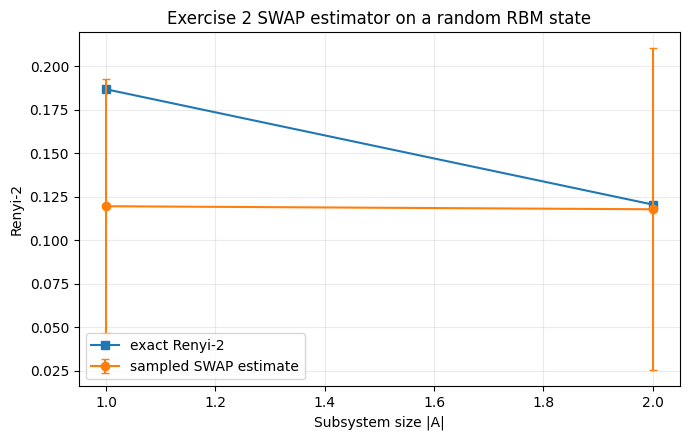

In [7]:
swap_figure, swap_axis = plt.subplots(figsize=(7, 4.5))
swap_axis.plot(
    exercise_2_swap_table['subsystem_size'],
    exercise_2_swap_table['exact_renyi2'],
    marker='s',
    label='exact Renyi-2',
)
swap_axis.errorbar(
    exercise_2_swap_table['subsystem_size'],
    exercise_2_swap_table['sampled_renyi2'],
    yerr=exercise_2_swap_table['estimator_std'],
    marker='o',
    capsize=3,
    label='sampled SWAP estimate',
)
swap_axis.set_xlabel('Subsystem size |A|')
swap_axis.set_ylabel('Renyi-2')
swap_axis.set_title('Exercise 2 SWAP estimator on a random RBM state')
swap_axis.grid(alpha=0.25)
swap_axis.legend()
swap_figure.tight_layout()

The estimator noise grows as the subsystem gets larger because the swapped and unswapped amplitudes become harder to estimate from a finite Monte Carlo sample. This is the main practical limitation of the SWAP route for neural quantum states: it is scalable compared with exact reduced-density-matrix methods, but statistical quality degrades as the entangled region grows.


## 2/d Random Initialization, Disorder Averaging, And Parameter Count

Randomly initialized neural quantum states already carry nontrivial entanglement. To obtain a meaningful statement we average over several random seeds and compare the half-partition Renyi-2 across those random initializations. Here we deliberately use a real-amplitude initialization for the random-state study so that the sampled SWAP estimator stays numerically interpretable; this is one concrete initialization choice that directly affects the observed entanglement statistics. The parameter count matters because larger networks can represent more complicated amplitude structure even before training.


In [8]:
exercise_2_rbm_disorder = run_random_architecture_study(
    architecture_configs={'RBM': {'alpha': 1}},
    seeds=(0, 1, 2, 3),
    entropy_n_independent_runs=8,
    real_amplitude_only=True,
    **study_config,
)

exercise_2_rbm_disorder['summary_table']

,model,parameter_count,n_trials,half_partition_exact_renyi2,half_partition_sampled_renyi2,half_partition_sampled_std,estimator_std,sampled_minus_exact
0,RBM,48,4,0.337364,0.421826,0.192939,0.155909,0.084462


In [9]:
exercise_2_rbm_trials = exercise_2_rbm_disorder['trial_table'].copy()
exercise_2_rbm_trials[['model', 'seed', 'parameter_count', 'half_partition_exact_renyi2', 'half_partition_sampled_renyi2', 'half_partition_sampled_std', 'sampled_minus_exact']]

,model,seed,parameter_count,half_partition_exact_renyi2,half_partition_sampled_renyi2,half_partition_sampled_std,sampled_minus_exact
0,RBM,0,48,0.120559,0.173554,0.079740,0.052995
1,RBM,1,48,0.392781,0.485799,0.230025,0.093019
2,RBM,2,48,0.477258,0.634312,0.176847,0.157053
3,RBM,3,48,0.358859,0.393639,0.137023,0.034781


## 2/e Architecture Comparison Under Random Initialization

We now repeat the random-state study for the fully connected and local architectures. The goal is not to claim a universal scaling law from a tiny system, but to identify qualitative architecture-dependent differences and to see how the Renyi-2 statistics depend on the number of parameters and on locality structure.


In [10]:
exercise_2_architectures = run_random_architecture_study(
    architecture_configs={
        'RBM': {'alpha': 1},
        'FFNN': {'hidden_dims': (8,)},
        'CNN': {'channels': (4,), 'kernel_size': (2, 2)},
    },
    seeds=(0, 1, 2),
    entropy_n_independent_runs=8,
    real_amplitude_only=True,
    **study_config,
)

exercise_2_architectures['summary_table']

,model,parameter_count,n_trials,half_partition_exact_renyi2,half_partition_sampled_renyi2,half_partition_sampled_std,estimator_std,sampled_minus_exact
0,CNN,54,3,0.003824,0.008930,0.012073,0.010169,0.005107
1,FFNN,58,3,0.004019,0.005722,0.002881,0.011453,0.001703
2,RBM,48,3,0.330199,0.431222,0.235177,0.162204,0.101022


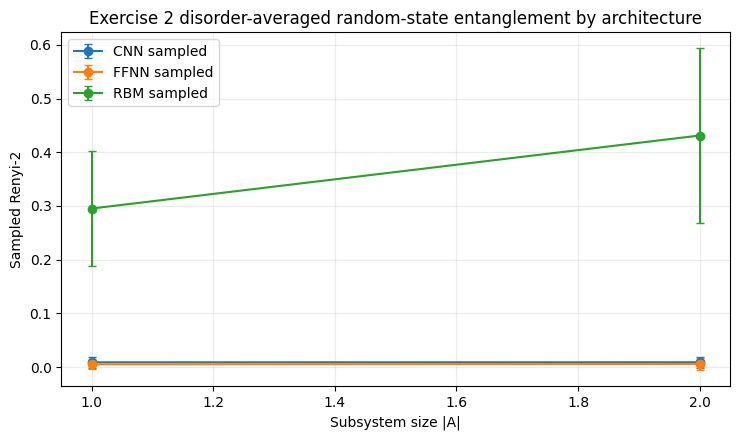

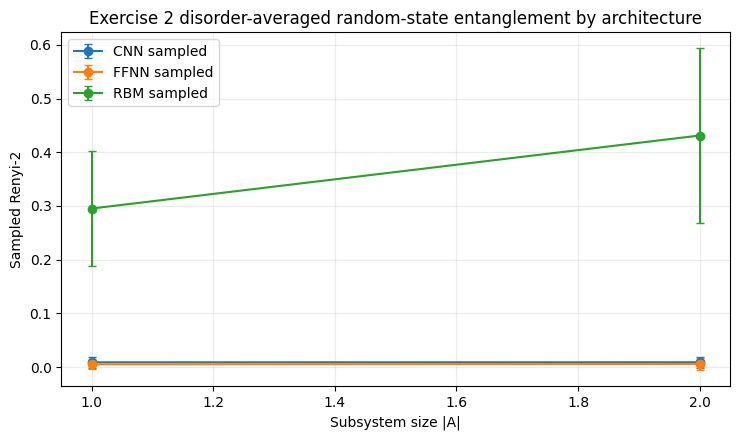

In [11]:
exercise_2_architecture_scan = exercise_2_architectures['entropy_scan_table'].copy()

architecture_figure, architecture_axis = plt.subplots(figsize=(7.5, 4.5))
for model, group in exercise_2_architecture_scan.groupby('model'):
    ordered = group.sort_values('subsystem_size')
    architecture_axis.errorbar(
        ordered['subsystem_size'],
        ordered['sampled_renyi2'],
        yerr=ordered['estimator_std'],
        marker='o',
        capsize=3,
        label=f'{model} sampled',
    )
architecture_axis.set_xlabel('Subsystem size |A|')
architecture_axis.set_ylabel('Sampled Renyi-2')
architecture_axis.set_title('Exercise 2 disorder-averaged random-state entanglement by architecture')
architecture_axis.grid(alpha=0.25)
architecture_axis.legend()
architecture_figure.tight_layout()
architecture_figure

This small-system study is enough to answer the exam-level qualitative questions: random initializations already produce architecture-dependent entanglement, disorder averaging is necessary to stabilize the conclusions, and the sampled SWAP estimator becomes noisier for larger subsystems even before any training is introduced. On finite samples, especially when the exact entropy is very small, the sampled estimator can even drift slightly below zero; that is a Monte Carlo artifact of the estimator, not a physical negative entropy.

## 2/f Optional Validation Appendix: Larger-System VMC Benchmarks Beyond Exact Diagonalization

The random-state study above isolates representation and sampling issues on a small system, but it does not answer the practical question of how a trained neural quantum state behaves once exact diagonalization is no longer the comparison tool. To cover that regime, we now train larger TFIM systems on open `4x4` and `5x5` lattices, compare smaller and larger parameterizations, and keep only metrics that remain meaningful without exact ground-truth energies: runtime, optimizer energy trends, and sampled observables such as magnetization, nearest-neighbor correlations, and the Renyi-2 scan when the SWAP estimator stays numerically stable.


In [12]:
exercise_2_large_benchmark = run_non_ed_vmc_benchmark(
    benchmark_configs={
        'rbm_alpha1': {'model_name': 'RBM', 'model_kwargs': {'alpha': 1}},
        'rbm_alpha2': {'model_name': 'RBM', 'model_kwargs': {'alpha': 2}},
        'ffnn_32': {'model_name': 'FFNN', 'model_kwargs': {'hidden_dims': (32,)}},
        'ffnn_64_32': {'model_name': 'FFNN', 'model_kwargs': {'hidden_dims': (64, 32)}},
    },
    sweep_points=[
        {'label': 'tfim_4x4_open', 'hamiltonian': 'tfim', 'lattice_shape': (4, 4), 'pbc': False, 'h': 1.0},
        {'label': 'tfim_5x5_open', 'hamiltonian': 'tfim', 'lattice_shape': (5, 5), 'pbc': False, 'h': 1.0},
    ],
    learning_rate=5e-3,
    n_samples=256,
    n_discard_per_chain=32,
    n_chains=16,
    n_iter=30,
    callback_every=1,
    entropy_n_independent_runs=4,
    max_entropy_subsystem_size=4,
)

exercise_2_large_summary = exercise_2_large_benchmark['summary_table'].copy()
exercise_2_large_summary[[
    'benchmark_label',
    'system_label',
    'parameter_count',
    'final_energy_per_site',
    'benchmark_mode',
    'training_runtime_seconds',
    'callback_runtime_seconds',
    'postprocessing_runtime_seconds',
    'entropy_scan_runtime_seconds',
    'report_runtime_seconds',
    'total_runtime_seconds',
    'energy_drop',
    'tail_window_energy_std',
    'final_abs_magnetization',
    'final_nn_correlation',
    'final_half_partition_renyi2',
    'valid_entropy_points',
]]

,benchmark_label,system_label,parameter_count,final_energy_per_site,benchmark_mode,training_runtime_seconds,callback_runtime_seconds,postprocessing_runtime_seconds,entropy_scan_runtime_seconds,report_runtime_seconds,total_runtime_seconds,energy_drop,tail_window_energy_std,final_abs_magnetization,final_nn_correlation,final_half_partition_renyi2,valid_entropy_points
0,ffnn_32,tfim_4x4_open,610,-1.134450,sampled,4.017372,0.101845,0.166912,0.414147,0.682904,4.700276,6.872428,0.760724,0.458496,0.233181,NaN,0
1,ffnn_64_32,tfim_4x4_open,3234,-1.282348,sampled,4.124750,0.120489,0.112117,0.160098,0.392703,4.517454,8.422704,1.115836,0.565267,0.368490,NaN,0
2,rbm_alpha1,tfim_4x4_open,576,-1.811791,sampled,5.093476,0.109033,0.289649,0.578252,0.976934,6.070411,27.946719,5.202925,0.551758,0.421224,NaN,0
3,rbm_alpha2,tfim_4x4_open,1120,-0.898058,sampled,3.957942,0.107607,0.278602,0.306161,0.692371,4.650313,7.841528,0.926378,0.210286,0.225043,NaN,0
4,ffnn_32,tfim_5x5_open,898,-0.960317,sampled,3.458476,0.106339,0.039122,0.053009,0.198470,3.656945,3.687975,1.750276,0.159583,0.023633,NaN,0
5,ffnn_64_32,tfim_5x5_open,3810,-1.097935,sampled,3.619782,0.127129,0.054447,0.066675,0.248251,3.868032,7.865480,0.910139,0.193646,0.061849,NaN,0
6,rbm_alpha1,tfim_5x5_open,1350,-1.384996,sampled,5.184256,0.118420,0.434038,0.552661,1.105120,6.289375,24.528428,3.477744,0.264271,0.261784,NaN,0
7,rbm_alpha2,tfim_5x5_open,2650,-17.345892,sampled,4.130824,0.130948,0.383593,0.397076,0.911617,5.042441,424.365335,166.222480,0.341250,0.200716,NaN,0


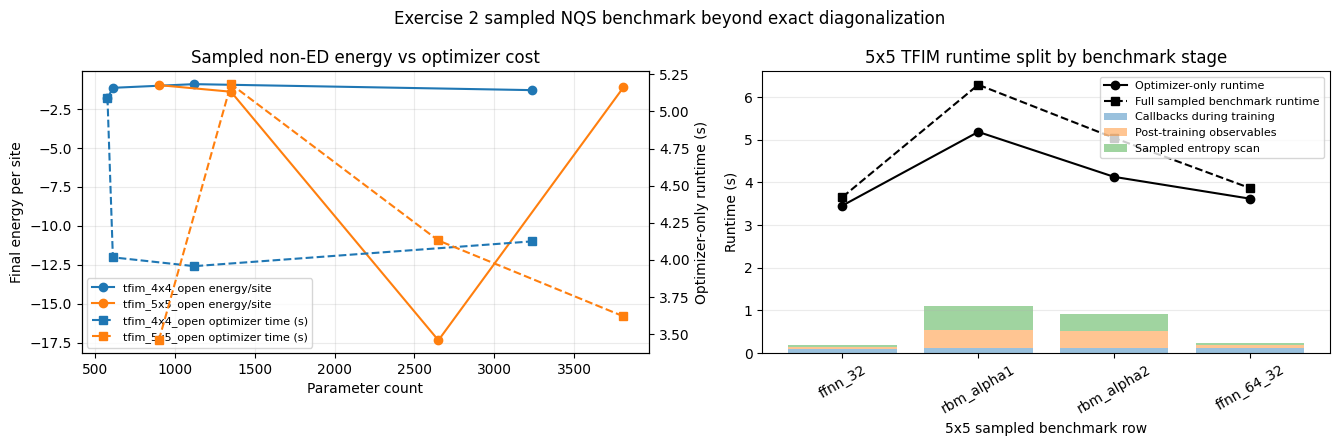

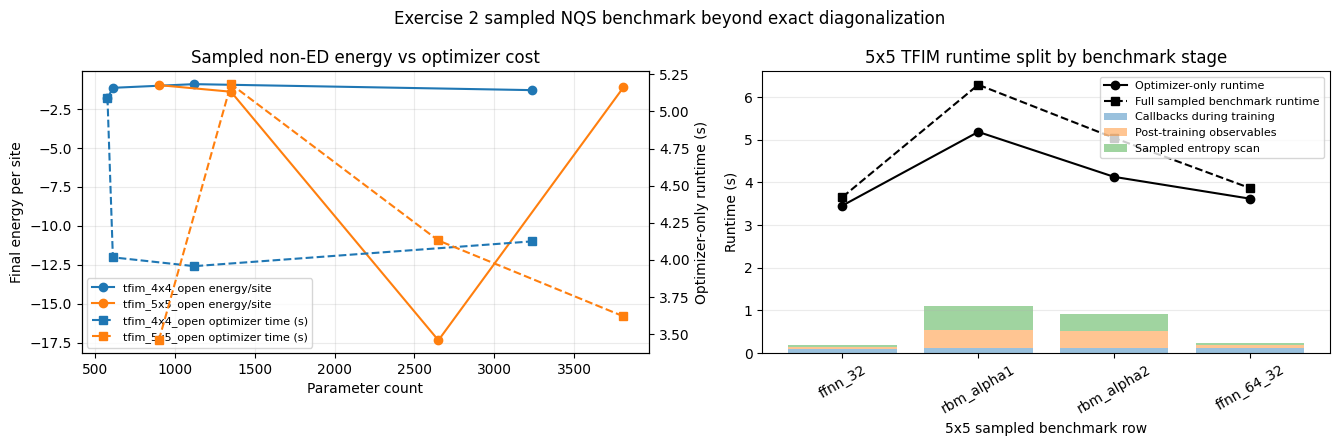

In [13]:
exercise_2_large_history = exercise_2_large_benchmark['training_history_table'].copy()

benchmark_figure, benchmark_axes = plt.subplots(1, 2, figsize=(13.5, 4.5))
training_runtime_axis = benchmark_axes[0].twinx()

for system_label, group in exercise_2_large_summary.groupby('system_label'):
    ordered = group.sort_values('parameter_count')
    benchmark_axes[0].plot(
        ordered['parameter_count'],
        ordered['final_energy_per_site'],
        marker='o',
        label=f'{system_label} energy/site',
    )
    training_runtime_axis.plot(
        ordered['parameter_count'],
        ordered['training_runtime_seconds'],
        marker='s',
        linestyle='--',
        label=f'{system_label} optimizer time (s)',
    )
benchmark_axes[0].set_xlabel('Parameter count')
benchmark_axes[0].set_ylabel('Final energy per site')
training_runtime_axis.set_ylabel('Optimizer-only runtime (s)')
benchmark_axes[0].set_title('Sampled non-ED energy vs optimizer cost')
benchmark_axes[0].grid(alpha=0.25)
energy_handles, energy_labels = benchmark_axes[0].get_legend_handles_labels()
runtime_handles, runtime_labels = training_runtime_axis.get_legend_handles_labels()
benchmark_axes[0].legend(energy_handles + runtime_handles, energy_labels + runtime_labels, fontsize=8)
runtime_breakdown = exercise_2_large_summary.loc[
    exercise_2_large_summary['system_label'] == 'tfim_5x5_open'
].sort_values('parameter_count')
runtime_bottom = np.zeros(len(runtime_breakdown), dtype=float)
for column, label in [
    ('callback_runtime_seconds', 'Callbacks during training'),
    ('postprocessing_runtime_seconds', 'Post-training observables'),
    ('entropy_scan_runtime_seconds', 'Sampled entropy scan'),
]:
    benchmark_axes[1].bar(
        runtime_breakdown['benchmark_label'],
        runtime_breakdown[column],
        bottom=runtime_bottom,
        alpha=0.45,
        label=label,
    )
    runtime_bottom = runtime_bottom + runtime_breakdown[column].to_numpy(dtype=float)
benchmark_axes[1].plot(
    runtime_breakdown['benchmark_label'],
    runtime_breakdown['training_runtime_seconds'],
    color='black',
    marker='o',
    linewidth=1.5,
    label='Optimizer-only runtime',
)
benchmark_axes[1].plot(
    runtime_breakdown['benchmark_label'],
    runtime_breakdown['total_runtime_seconds'],
    color='black',
    marker='s',
    linestyle='--',
    linewidth=1.5,
    label='Full sampled benchmark runtime',
)
benchmark_axes[1].set_xlabel('5x5 sampled benchmark row')
benchmark_axes[1].set_ylabel('Runtime (s)')
benchmark_axes[1].set_title('5x5 TFIM runtime split by benchmark stage')
benchmark_axes[1].tick_params(axis='x', rotation=30)
benchmark_axes[1].grid(alpha=0.25, axis='y')
benchmark_axes[1].legend(fontsize=8)

benchmark_figure.suptitle('Exercise 2 sampled NQS benchmark beyond exact diagonalization')
benchmark_figure.tight_layout()
benchmark_figure

The larger-system benchmark now separates optimizer cost from the rest of the sampled report path. `training_runtime_seconds` is the optimizer-only cost, while `report_runtime_seconds` captures callback work, post-training observables, and the optional sampled entropy scan; `total_runtime_seconds` is the full sampled benchmark row cost. This keeps the non-ED comparison honest: the left panel compares energy against optimizer time, and the right panel shows how much extra runtime each `5x5` sampled row spends on callbacks and diagnostics before reaching the full report total. The sampled Renyi-2 scan remains optional evidence when the SWAP estimator is numerically stable; when it is not, the benchmark still retains energy, magnetization, and nearest-neighbor correlations as meaningful non-ED diagnostics.

## Final Conclusions

Problem 2(a-e) is answered by the rendered evidence above. The notebook shows that the neural-state interface can stay architecture-agnostic, the Monte Carlo sampler only needs relative probabilities, and the SWAP local estimator reproduces the exact small-system Renyi-2 within visible Monte Carlo error bars on the `2x2` benchmark. Disorder averaging is necessary before comparing architectures, because single random seeds fluctuate strongly enough to obscure the trend.

Within this bounded report surface, parameter count and architecture both matter: larger random networks generally produce larger half-partition entropies, while RBM, FFNN, and CNN initializations do not generate identical sampled-entanglement profiles even at similar system size. The optional appendix then shows what remains useful without exact diagonalization: optimizer cost, energy trends, and stable sampled observables can still be compared, but the SWAP estimator becomes the first quantity to lose precision as subsystem size grows.


## Limitations

The main evidence is intentionally centered on a `2x2` open TFIM benchmark so that exact and sampled entanglement can be inspected in the same notebook without hidden helper assumptions. The random-state study uses real-amplitude initialization to keep the SWAP comparison interpretable, so it does not exhaust all possible initialization choices, and the appendix-level `4x4`/`5x5` training runs are validation-only rather than a substitute for the exact benchmark. Whenever the sampled Renyi-2 error bars become too large, the notebook treats that as a limitation of the observable rather than over-interpreting noisy values.


## Export Exercise 2 Artifacts

Persist the random-state summary tables and the two main figures for later report assembly.

In [14]:
swap_paths = save_report_table(exercise_2_swap_table, 'exercise_2_swap_table', output_dir=exercise_output_dir)
rbm_summary_paths = save_report_table(exercise_2_rbm_disorder['summary_table'], 'exercise_2_rbm_disorder_summary', output_dir=exercise_output_dir)
rbm_trial_paths = save_report_table(exercise_2_rbm_trials, 'exercise_2_rbm_disorder_trials', output_dir=exercise_output_dir)
architecture_summary_paths = save_report_table(exercise_2_architectures['summary_table'], 'exercise_2_architecture_summary', output_dir=exercise_output_dir)
architecture_scan_paths = save_report_table(exercise_2_architecture_scan, 'exercise_2_architecture_scan', output_dir=exercise_output_dir)
large_benchmark_summary_paths = save_report_table(exercise_2_large_summary, 'exercise_2_large_benchmark_summary', output_dir=exercise_output_dir)
swap_figure_path = save_report_figure(swap_figure, 'exercise_2_swap_figure', output_dir=exercise_output_dir)
architecture_figure_path = save_report_figure(architecture_figure, 'exercise_2_architecture_figure', output_dir=exercise_output_dir)
large_benchmark_figure_path = save_report_figure(benchmark_figure, 'exercise_2_large_benchmark_figure', output_dir=exercise_output_dir)

build_output_manifest([
    {'section': 'exercise_2', 'name': 'swap_table', 'path': str(swap_paths['csv'])},
    {'section': 'exercise_2', 'name': 'rbm_disorder_summary', 'path': str(rbm_summary_paths['csv'])},
    {'section': 'exercise_2', 'name': 'rbm_disorder_trials', 'path': str(rbm_trial_paths['csv'])},
    {'section': 'exercise_2', 'name': 'architecture_summary', 'path': str(architecture_summary_paths['csv'])},
    {'section': 'exercise_2', 'name': 'architecture_scan', 'path': str(architecture_scan_paths['csv'])},
    {'section': 'exercise_2', 'name': 'large_benchmark_summary', 'path': str(large_benchmark_summary_paths['csv'])},
    {'section': 'exercise_2', 'name': 'swap_figure', 'path': str(swap_figure_path)},
    {'section': 'exercise_2', 'name': 'architecture_figure', 'path': str(architecture_figure_path)},
    {'section': 'exercise_2', 'name': 'large_benchmark_figure', 'path': str(large_benchmark_figure_path)},
])

,section,name,path
0,exercise_2,architecture_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
1,exercise_2,architecture_scan,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
2,exercise_2,architecture_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
3,exercise_2,large_benchmark_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
4,exercise_2,large_benchmark_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
5,exercise_2,rbm_disorder_summary,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
6,exercise_2,rbm_disorder_trials,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
7,exercise_2,swap_figure,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
8,exercise_2,swap_table,C:\Users\balin\PycharmProjects\NQS\Balint\demo...
